In [1]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

print("Libraries loaded successfully!")


Libraries loaded successfully!


In [2]:
# Loading the dataset
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# First look
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")

Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [3]:
# Basic exploration
print(f"Shape: {df.shape}")
print(f"\n=== DATA TYPES ===")
print(df.dtypes)

print(f"\n=== MISSING VALUES ===")
print(df.isnull().sum())

print(f"\n=== CHURN DISTRIBUTION ===")
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {df['Churn'].value_counts(normalize=True)['Yes']:.1%}")

Shape: (7043, 21)

=== DATA TYPES ===
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

=== MISSING VALUES ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contra

In [4]:
# Data cleaning
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Convert Churn to binary
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Check missing values after conversion
print("=== MISSING VALUES AFTER CONVERSION ===")
print(df[['TotalCharges', 'Churn_Binary']].isnull().sum())

# Fill missing TotalCharges with 0 (new customers with no charges yet)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("\n=== BASIC STATISTICS ===")
display(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())

=== MISSING VALUES AFTER CONVERSION ===
TotalCharges    11
Churn_Binary     0
dtype: int64

=== BASIC STATISTICS ===


,tenure,MonthlyCharges,TotalCharges
count,"7,043.00","7,043.00","7,043.00"
mean,32.37,64.76,"2,279.73"
std,24.56,30.09,"2,266.79"
min,0.00,18.25,0.00
25%,9.00,35.50,398.55
50%,29.00,70.35,"1,394.55"
75%,55.00,89.85,"3,786.60"
max,72.00,118.75,"8,684.80"


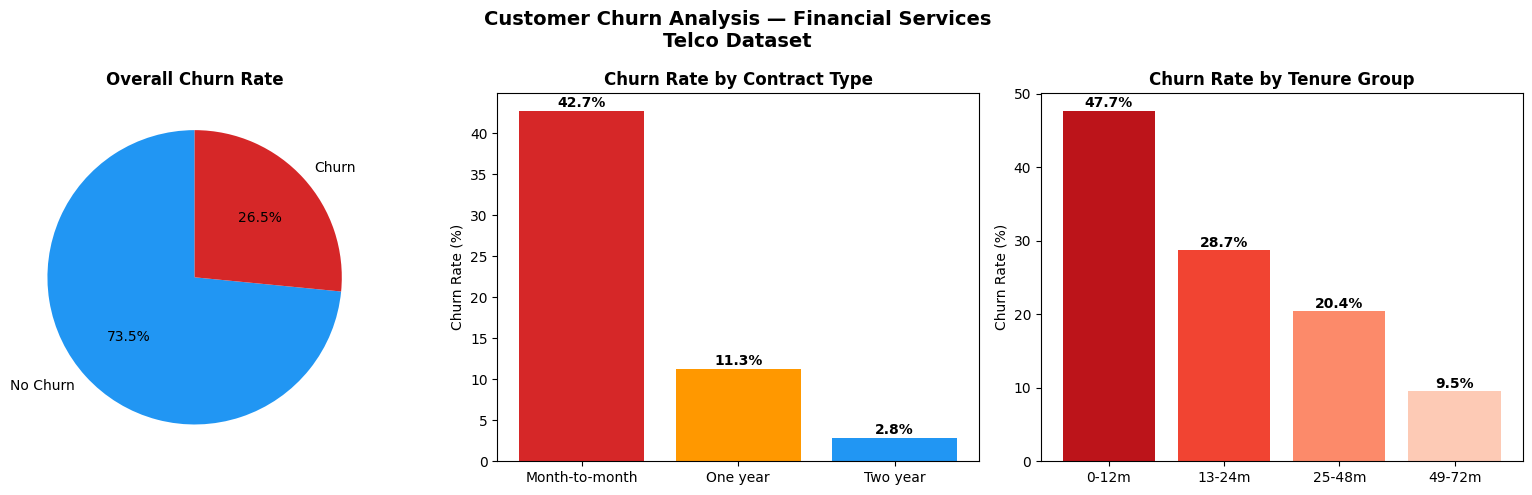

Chart saved!


In [5]:
# Churn distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1: Overall churn rate
churn_counts = df['Churn'].value_counts()
axes[0].pie(churn_counts, labels=['No Churn', 'Churn'], 
            autopct='%1.1f%%', colors=['#2196F3', '#d62728'],
            startangle=90)
axes[0].set_title('Overall Churn Rate', fontweight='bold')

# Chart 2: Churn by Contract Type
contract_churn = df.groupby('Contract')['Churn_Binary'].mean().sort_values(ascending=False)
axes[1].bar(contract_churn.index, contract_churn.values * 100, 
            color=['#d62728', '#FF9800', '#2196F3'])
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Churn Rate by Contract Type', fontweight='bold')
for i, v in enumerate(contract_churn.values * 100):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Chart 3: Churn by Tenure Group
df['Tenure_Group'] = pd.cut(df['tenure'], 
                             bins=[0, 12, 24, 48, 72], 
                             labels=['0-12m', '13-24m', '25-48m', '49-72m'])
tenure_churn = df.groupby('Tenure_Group', observed=True)['Churn_Binary'].mean()
axes[2].bar(tenure_churn.index, tenure_churn.values * 100, color=sns.color_palette("Reds_r", 4))
axes[2].set_ylabel('Churn Rate (%)')
axes[2].set_title('Churn Rate by Tenure Group', fontweight='bold')
for i, v in enumerate(tenure_churn.values * 100):
    axes[2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Customer Churn Analysis — Financial Services\nTelco Dataset', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/churn_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

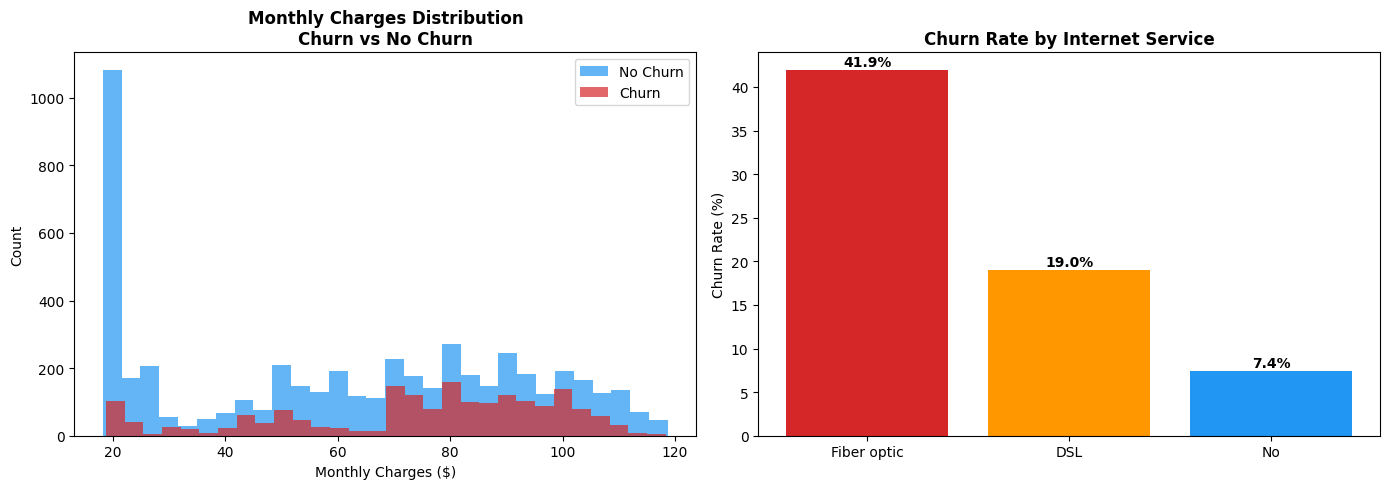

Chart saved!


In [6]:
# Churn by Monthly Charges and Internet Service
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Monthly Charges distribution - Churn vs No Churn
axes[0].hist(df[df['Churn']=='No']['MonthlyCharges'], 
             bins=30, alpha=0.7, color='#2196F3', label='No Churn')
axes[0].hist(df[df['Churn']=='Yes']['MonthlyCharges'], 
             bins=30, alpha=0.7, color='#d62728', label='Churn')
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].set_ylabel('Count')
axes[0].set_title('Monthly Charges Distribution\nChurn vs No Churn', fontweight='bold')
axes[0].legend()

# Chart 2: Churn by Internet Service
internet_churn = df.groupby('InternetService')['Churn_Binary'].mean().sort_values(ascending=False)
axes[1].bar(internet_churn.index, internet_churn.values * 100,
            color=['#d62728', '#FF9800', '#2196F3'])
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Churn Rate by Internet Service', fontweight='bold')
for i, v in enumerate(internet_churn.values * 100):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/churn_charges_internet.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

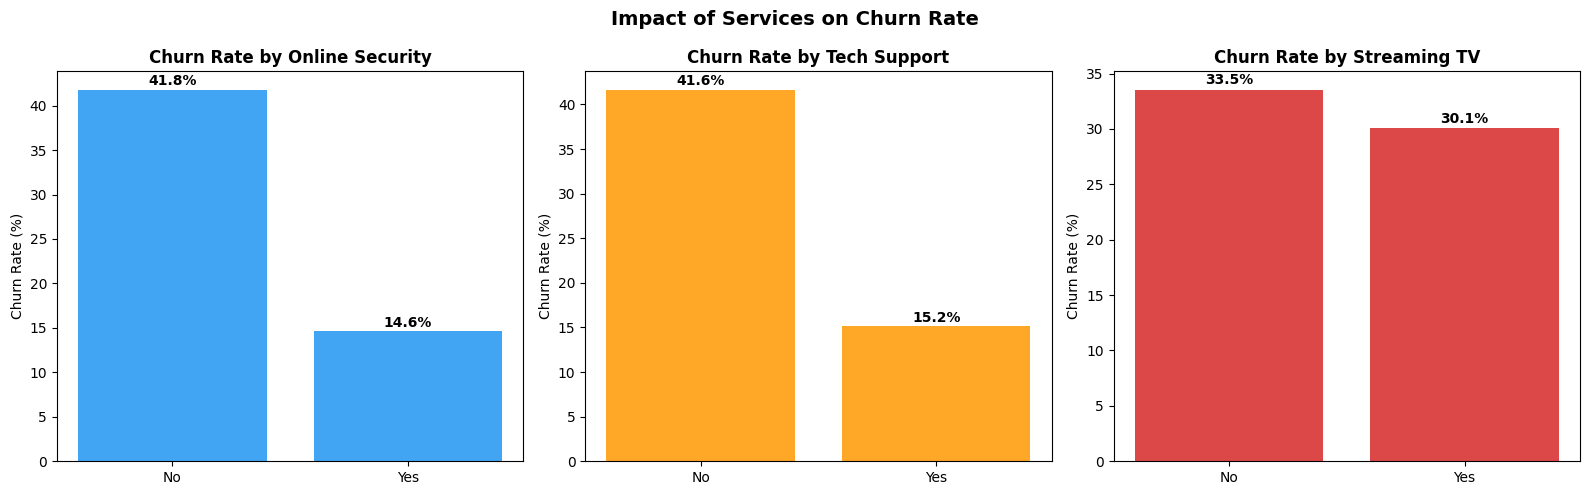

Chart saved!


In [7]:
# Churn by key services
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

services = ['OnlineSecurity', 'TechSupport', 'StreamingTV']
titles = ['Online Security', 'Tech Support', 'Streaming TV']
colors = ['#2196F3', '#FF9800', '#d62728']

for i, (service, title, color) in enumerate(zip(services, titles, colors)):
    service_churn = df.groupby(service)['Churn_Binary'].mean()
    service_churn = service_churn[service_churn.index != 'No internet service']
    
    axes[i].bar(service_churn.index, service_churn.values * 100, color=color, alpha=0.85)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_title(f'Churn Rate by {title}', fontweight='bold')
    for j, v in enumerate(service_churn.values * 100):
        axes[i].text(j, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Impact of Services on Churn Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/churn_by_services.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

In [8]:
# Financial Impact of Churn
churned = df[df['Churn'] == 'Yes']
retained = df[df['Churn'] == 'No']

# Key metrics
monthly_revenue_lost = churned['MonthlyCharges'].sum()
avg_monthly_lost = churned['MonthlyCharges'].mean()
avg_tenure_churned = churned['tenure'].mean()
revenue_lost_lifetime = churned['TotalCharges'].sum()

print("=== FINANCIAL IMPACT OF CHURN ===")
print(f"Customers Lost:              {len(churned):,}")
print(f"Monthly Revenue Lost:        ${monthly_revenue_lost:,.2f}")
print(f"Projected Annual Loss:       ${monthly_revenue_lost * 12:,.2f}")
print(f"Avg Monthly Charge (churned):${avg_monthly_lost:,.2f}")
print(f"Avg Tenure Before Churning:  {avg_tenure_churned:.1f} months")
print(f"Total Lifetime Value Lost:   ${revenue_lost_lifetime:,.2f}")

print("\n=== RETAINED CUSTOMERS ===")
print(f"Customers Retained:          {len(retained):,}")
print(f"Monthly Revenue Retained:    ${retained['MonthlyCharges'].sum():,.2f}")
print(f"Avg Monthly Charge:          ${retained['MonthlyCharges'].mean():,.2f}")

=== FINANCIAL IMPACT OF CHURN ===
Customers Lost:              1,869
Monthly Revenue Lost:        $139,130.85
Projected Annual Loss:       $1,669,570.20
Avg Monthly Charge (churned):$74.44
Avg Tenure Before Churning:  18.0 months
Total Lifetime Value Lost:   $2,862,926.90

=== RETAINED CUSTOMERS ===
Customers Retained:          5,174
Monthly Revenue Retained:    $316,985.75
Avg Monthly Charge:          $61.27


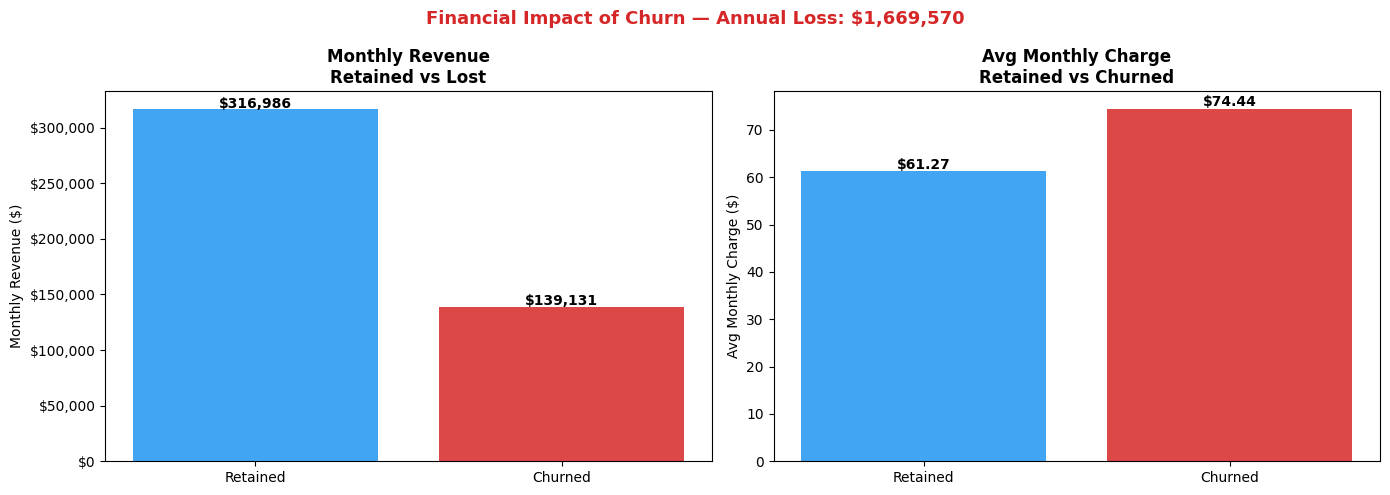

Chart saved!


In [9]:
# Financial Impact Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Monthly Revenue - Retained vs Lost
categories = ['Retained', 'Churned']
values = [retained['MonthlyCharges'].sum(), churned['MonthlyCharges'].sum()]
colors = ['#2196F3', '#d62728']
bars = axes[0].bar(categories, values, color=colors, alpha=0.85)
axes[0].set_ylabel('Monthly Revenue ($)')
axes[0].set_title('Monthly Revenue\nRetained vs Lost', fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                f'${val:,.0f}', ha='center', fontweight='bold')

# Chart 2: Avg Monthly Charge comparison
avg_values = [retained['MonthlyCharges'].mean(), churned['MonthlyCharges'].mean()]
bars2 = axes[1].bar(categories, avg_values, color=colors, alpha=0.85)
axes[1].set_ylabel('Avg Monthly Charge ($)')
axes[1].set_title('Avg Monthly Charge\nRetained vs Churned', fontweight='bold')
for bar, val in zip(bars2, avg_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'${val:.2f}', ha='center', fontweight='bold')

plt.suptitle(f'Financial Impact of Churn — Annual Loss: $1,669,570',
             fontsize=13, fontweight='bold', color='#d62728')
plt.tight_layout()
plt.savefig('../docs/financial_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

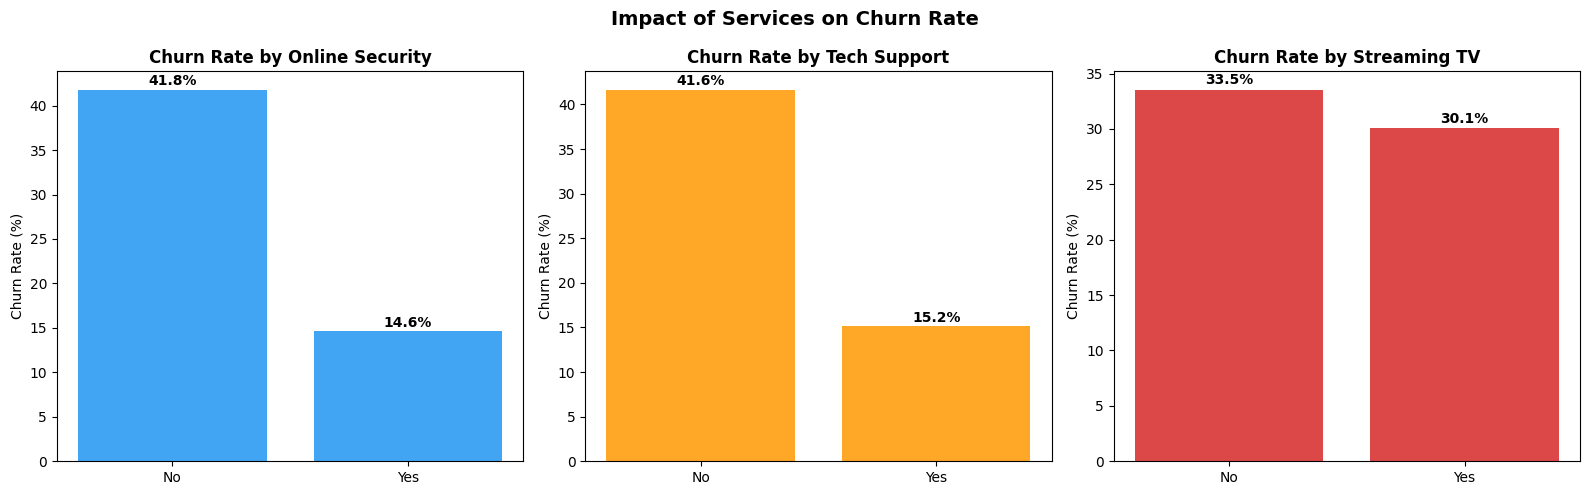

Chart saved!


In [10]:
# Churn by key services
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

services = ['OnlineSecurity', 'TechSupport', 'StreamingTV']
titles = ['Online Security', 'Tech Support', 'Streaming TV']
colors = ['#2196F3', '#FF9800', '#d62728']

for i, (service, title, color) in enumerate(zip(services, titles, colors)):
    service_churn = df.groupby(service)['Churn_Binary'].mean()
    service_churn = service_churn[service_churn.index != 'No internet service']
    
    axes[i].bar(service_churn.index, service_churn.values * 100, color=color, alpha=0.85)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_title(f'Churn Rate by {title}', fontweight='bold')
    for j, v in enumerate(service_churn.values * 100):
        axes[i].text(j, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Impact of Services on Churn Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/churn_by_services.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

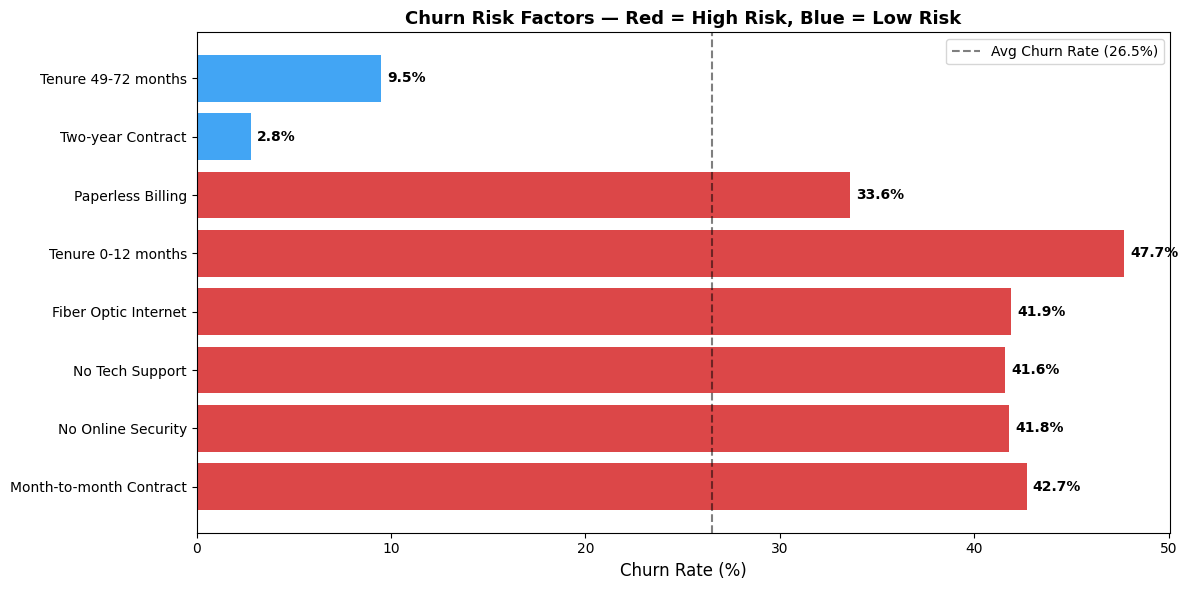

Chart saved!


In [11]:
# Churn Risk Summary - Heatmap style
churn_factors = {
    'Month-to-month Contract': 42.7,
    'No Online Security': 41.8,
    'No Tech Support': 41.6,
    'Fiber Optic Internet': 41.9,
    'Tenure 0-12 months': 47.7,
    'Paperless Billing': 33.6,
    'Two-year Contract': 2.8,
    'Tenure 49-72 months': 9.5
}

fig, ax = plt.subplots(figsize=(12, 6))

factors = list(churn_factors.keys())
values = list(churn_factors.values())
colors = ['#d62728' if v > 30 else '#2196F3' for v in values]

bars = ax.barh(factors, values, color=colors, alpha=0.85)
ax.set_xlabel('Churn Rate (%)', fontsize=12)
ax.set_title('Churn Risk Factors — Red = High Risk, Blue = Low Risk',
             fontsize=13, fontweight='bold')
ax.axvline(x=26.5, color='black', linestyle='--', alpha=0.5, label='Avg Churn Rate (26.5%)')
ax.legend()

for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/churn_risk_factors.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")